# choose the format and the path you want the dataset to be saved

In [ ]:
import pathlib
import yaml

# Load yaml file
with open('settings.yaml') as f:
    settings = yaml.safe_load(f)

# choose roboflow dataset from the yaml file
chosen_dataset=settings["roboflow_datasets"]["ebi_full"]

# choose format
format="yolov5"
# formats include: clip, coco, coco-mmdetection, createml, darknet, multiclass, tensorflow, tfrecord, voc, yolokeras, yolov4pytorch, yolov4scaled, yolov5-obb, yolov5pytorch, yolov7pytorch, yolov8, yolov8-obb, yolov9, yolov11, yolov12, mt-yolov6, retinanet, benchmarker, paligemma, paligemma-txt, florence2-od, openai

# choose the parent directory where all your datasets are stored
datasets_parent=pathlib.Path.cwd().parent / "datasets"
destination_path = pathlib.Path(datasets_parent / chosen_dataset['type'] / f"{chosen_dataset['type']}-{chosen_dataset['version']}-{format}")
fiftyone_path=pathlib.Path(datasets_parent / chosen_dataset['type'] / f"{chosen_dataset['project']}-{chosen_dataset['version']}-{format}-for-fiftyone")
# labelstudio_path=pathlib.Path("data") / "local-files" / "?d=datasets" / chosen_dataset["type"] / f"{chosen_dataset["project"]}-{chosen_dataset["version"]}-{format}"

In [2]:
import shutil
import subprocess
import roboflow
import os
import pathlib
import yaml

# download dataset
rf = roboflow.Roboflow(api_key=chosen_dataset["api_key"])
print("key accepted")
project = rf.workspace(chosen_dataset["workspace"]).project(chosen_dataset["project"])
print(f"project {chosen_dataset['project']} found in workspace {chosen_dataset['workspace']}")
version = project.version(chosen_dataset["version"])
print(f"version {chosen_dataset['version']} found in project {chosen_dataset['project']}")
dataset = version.download(format)

# copy shinanigans
shutil.copytree(dataset.location, destination_path, dirs_exist_ok=True)
shutil.rmtree(dataset.location)
subprocess.run(["chmod", "-R", "777", destination_path])

# check everything went fine
print(f"downloaded and copied: {destination_path.exists()}")
print(f"Total size: {sum(f.stat().st_size for f in destination_path.rglob('*')) / (1024*1024):.1f} MB")
print(f"Readable: {os.access(destination_path, os.R_OK)}")
print(f"Writable: {os.access(destination_path, os.W_OK)}")
print(f"Executable: {os.access(destination_path, os.X_OK)}")

key accepted
loading Roboflow workspace...
loading Roboflow project...
project ebi-fused found in workspace made-srcnb
version 4 found in project ebi-fused



Extracting Dataset Version Zip to ebi-fused-4 in yolov5pytorch:: 100%|██████████| 6808/6808 [00:00<00:00, 11367.50it/s]


downloaded and copied: True
Total size: 135.8 MB
Readable: True
Writable: True
Executable: True


# convert to fiftyone

In [ ]:
# Convert folder structure to FiftyOne YOLOv5 format
# Some reformatting is done here since roboflow and fiftyone have a different understanding of the yolo format

import os
import shutil
import yaml
from pathlib import Path


def convert_to_fiftyone_yolo_format(destination_path, reformatted_path):
    """Convert Roboflow YOLO structure to FiftyOne YOLOv5 structure"""
    
    fiftyone_path.mkdir(exist_ok=True)

    images_dir = fiftyone_path / "images"
    labels_dir = fiftyone_path / "labels"

    images_dir.mkdir(exist_ok=True)
    labels_dir.mkdir(exist_ok=True)
    
    # Process each split
    splits = ["train", "valid", "test"]
    for split in splits:
        old_split_dir = destination_path / split
    
        if old_split_dir.exists():
            print(f"Processing {split} split...")
            
            # Move images
            old_images = old_split_dir / "images"
            new_images = images_dir / split
            
            if old_images.exists() and any(old_images.iterdir()):
                if new_images.exists():
                    shutil.rmtree(new_images)
                shutil.move(str(old_images), str(new_images))
                print(f"  Moved images: {old_images} -> {new_images}")
            else:
                print(f"  No images found in {old_images}")
        
            # Move labels
            old_labels = old_split_dir / "labels"
            new_labels = labels_dir / split
            
            if old_labels.exists() and any(old_labels.iterdir()):
                if new_labels.exists():
                    shutil.rmtree(new_labels)
                shutil.move(str(old_labels), str(new_labels))
                print(f"  Moved labels: {old_labels} -> {new_labels}")
            else:
                print(f"  No labels found in {old_labels}")
        else:
            print(f"Split {split} not found, skipping...")
    
    # Update YAML file - read from original, save as new file
    original_yaml_path = destination_path / "data.yaml"  # Original file
    new_yaml_path = reformatted_path / "dataset.yaml"       # New file in reformatted dir
    
    if original_yaml_path.exists():
        with open(original_yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        
        # Update paths to FiftyOne format  
        data.update({
            'train': './images/train',
            'val': './images/valid', 
            'test': './images/test'
        })
        
        # Write to NEW data.yaml in reformatted directory
        with open(new_yaml_path, 'w') as f:
            yaml.dump(data, f, default_flow_style=False)
        

# Run the conversion
convert_to_fiftyone_yolo_format(destination_path, fiftyone_path)

# check everything went fine
print(f"converted: {fiftyone_path.exists()}")
print(f"Total size: {sum(f.stat().st_size for f in fiftyone_path.rglob('*')) / (1024*1024):.1f} MB")
print(f"Readable: {os.access(fiftyone_path, os.R_OK)}")
print(f"Writable: {os.access(fiftyone_path, os.W_OK)}")
print(f"Executable: {os.access(fiftyone_path, os.X_OK)}")
print("the original files are moved, not copied!")

Processing train split...
  Moved images: /home/freeze/GIT/onemanstreasure/datasets/multiclass/multiclass-4-yolov5/train/images -> /home/freeze/GIT/onemanstreasure/datasets/multiclass/ebi-fused-4-yolov5-for-fiftyone/images/train
  Moved labels: /home/freeze/GIT/onemanstreasure/datasets/multiclass/multiclass-4-yolov5/train/labels -> /home/freeze/GIT/onemanstreasure/datasets/multiclass/ebi-fused-4-yolov5-for-fiftyone/labels/train
Processing valid split...
  Moved images: /home/freeze/GIT/onemanstreasure/datasets/multiclass/multiclass-4-yolov5/valid/images -> /home/freeze/GIT/onemanstreasure/datasets/multiclass/ebi-fused-4-yolov5-for-fiftyone/images/valid
  Moved labels: /home/freeze/GIT/onemanstreasure/datasets/multiclass/multiclass-4-yolov5/valid/labels -> /home/freeze/GIT/onemanstreasure/datasets/multiclass/ebi-fused-4-yolov5-for-fiftyone/labels/valid
Processing test split...
  Moved images: /home/freeze/GIT/onemanstreasure/datasets/multiclass/multiclass-4-yolov5/test/images -> /home/f

In [5]:
import fiftyone as fo

name = str(chosen_dataset["project"]) + "-" + str(chosen_dataset["version"])

try:
    fo.delete_dataset(name)
    print(f"Deleted existing dataset: {name}")
except:
    print(f"No existing dataset named: {name}")

Deleted existing dataset: ebi-fused-4


In [6]:
import fiftyone as fo


# The splits to load
splits = ["train","test", "val"]
name = str(chosen_dataset["project"]) + "-" + str(chosen_dataset["version"])


# Load the dataset, using tags to mark the samples in each split

dataset = fo.Dataset(name)
for split in splits:
    dataset.add_dir(
        dataset_dir=fiftyone_path,
        dataset_type=fo.types.YOLOv5Dataset,
        split=split,
        tags=split,
)

# View summary info about the dataset
print(dataset)

# Print the first few samples in the dataset
print(dataset.head())

 100% |███████████████| 2720/2720 [2.6s elapsed, 0s remaining, 1.0K samples/s]       
 100% |█████████████████| 343/343 [326.0ms elapsed, 0s remaining, 1.1K samples/s]     
 100% |█████████████████| 335/335 [382.3ms elapsed, 0s remaining, 876.3 samples/s]     
Name:        ebi-fused-4
Media type:  image
Num samples: 3398
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
[<Sample: {
    'id': '68accad4606c8f348a6060c1',
    'media_type': 'image',
    'filepath': '/home/freeze/GIT/on

Computing metadata...
 100% |███████████████| 3398/3398 [661.1ms elapsed, 0s remaining, 5.1K samples/s]      



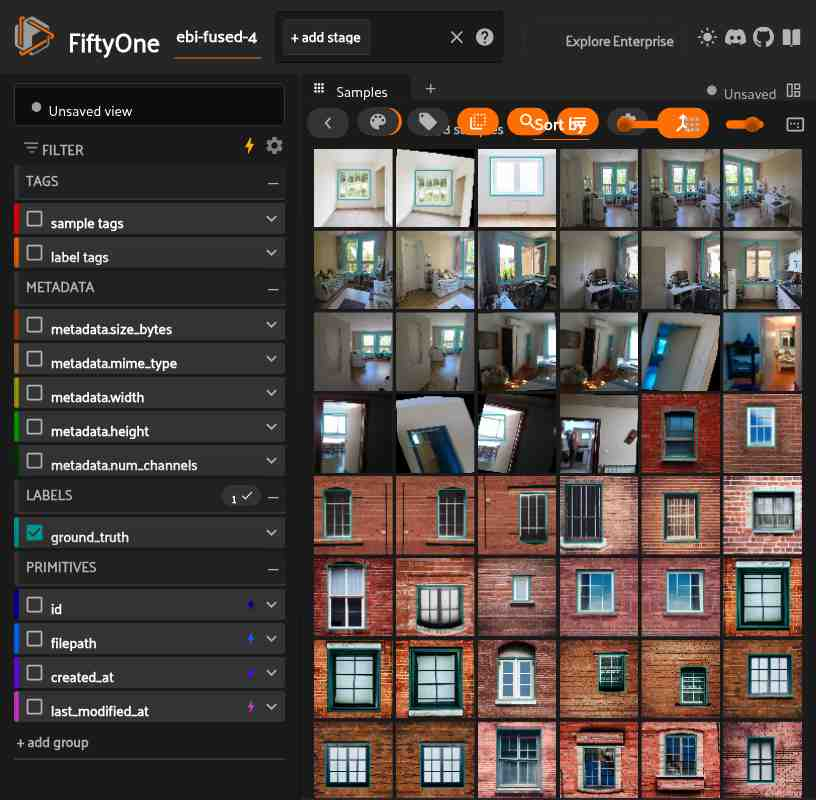

In [ ]:
dataset.compute_metadata()
session = fo.launch_app(dataset)

# convert to label studio (maybe needs updates with pathlib library used)

In [ ]:
%%script echo "Skipping this cell"
import yaml
import os

yaml_path = f"{destination_path}/data.yaml"
with open(yaml_path) as f:
    classes = yaml.safe_load(f).get("names", [])
    

for subfolder in os.listdir(destination_path):
    subfolder_path = os.path.join(destination_path, subfolder)
    if os.path.isdir(subfolder_path):
        classes_txt = os.path.join(subfolder_path, "classes.txt")
        with open(classes_txt, "w") as f:
            f.write("\n".join(classes))

In [ ]:
%%script echo "Skipping this cell"
import os
import subprocess

for subfolder in os.listdir(destination_path):
    subfolder_path = os.path.join(destination_path, subfolder)
    if os.path.isdir(subfolder_path):
        try:
            subprocess.run([
                "label-studio-converter", "import", "yolo",
                "-i", subfolder_path,
                "-o", f"{subfolder_path}/label-studio.json",
                "--image-root-url", f"{labelstudio_path}/{subfolder}/images"
            ])
        except Exception as e:
            print(f"Error processing {subfolder_path}: {e}")

In [ ]:
%%script echo "Skipping this cell"
print(destination_path)

In [ ]:
%%script echo "Skipping this cell"
!label-studio-converter import yolo \
  -i /mnt/EBI-SHARE/06_Data/labelstudio/datasets/multiclass/room312_and_leuthener-2-yolov8/valid \
  -o ls-tasks.json \
  --image-root-url /data/local-files/?d=datasets/multiclass/room312_and_leuthener-2-yolov8/valid/images

In [ ]:
%%script echo "Skipping this cell"
http://localhost:8081/data/local-files/?d=datasets/multiclass/ebi-fused-1/train/images/-47104722_jpg.rf.04ee0f9cbb75ffdfadc14e117275c20e.jpg